# Variational counterdiabatic driving of a thermal harmonic oscillator

A self-contained calculation and APS-style figure.  The bath inverse
temperature is ramped from `BETA_I` to `BETA_F`; the dissipator `D[a]` is
fitted variationally as the adiabatic gauge potential.  Increasing the
truncated Hilbert-space dimension exposes convergence to the untruncated
oscillator result.



In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.integrate import solve_ivp


# ============================================================================
# USER SETTINGS
# ============================================================================

OMEGA = 1.0
BATH_GAMMA = 1.0
BETA_I, BETA_F = 1.0, 3.0
T = 0.3
N_TIMES = 101

DIMS = [4, 6, 8, 10, 12]
SHOW_TIME_FRACTION = 0.50
MAX_FOCK_SHOWN = 8

USE_TEX = True
SAVE_FIGURE = True
OUTPUT_NAME = "QHO_variational_CD_APS.pdf"


# ============================================================================
# STYLE
# ============================================================================

ORANGE = "#E97C4A"
GREEN = "#4B8B3B"
BLUE = "#3366AA"
BLACK = "#000000"
MID_GREY = "#999999"

plt.rcParams.update({
    "text.usetex": USE_TEX,
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
if USE_TEX:
    plt.rcParams["text.latex.preamble"] = (
        r"\usepackage{amsmath} \usepackage{amssymb} \usepackage{mathptmx}"
    )




## Calculation



In [6]:
def annihilation_operator(dim):
    """Truncated lowering operator in the basis |0>,...,|dim-1>."""
    return np.diag(np.sqrt(np.arange(1, dim, dtype=float)), 1).astype(complex)


def dissipator(L, rho):
    """GKSL dissipator D[L](rho)."""
    LdagL = L.conj().T @ L
    return L @ rho @ L.conj().T - 0.5 * (LdagL @ rho + rho @ LdagL)


def thermal_state_and_derivative(dim, omega, beta):
    """Truncated thermal state and its exact beta derivative."""
    levels = np.arange(dim, dtype=float)
    weights = np.exp(-beta * omega * levels)
    probabilities = weights / weights.sum()
    rho = np.diag(probabilities).astype(complex)
    mean_n = probabilities @ levels
    drho_dbeta = np.diag(-omega * (levels - mean_n) * probabilities).astype(complex)
    return rho, drho_dbeta


def fit_lowering_agp(dim, omega, beta):
    """Fit gamma >= 0 in d_beta rho_ss = gamma D[a](rho_ss)."""
    a = annihilation_operator(dim)
    rho, target = thermal_state_and_derivative(dim, omega, beta)
    direction = dissipator(a, rho)

    denominator = np.vdot(direction, direction).real
    gamma = max(0.0, np.vdot(direction, target).real / denominator)
    residual = np.linalg.norm(target - gamma * direction, "fro")
    relative_residual = residual / max(np.linalg.norm(target, "fro"), 1e-15)
    return gamma, relative_residual


def trace_distance(rho, sigma):
    """Trace distance 1/2 ||rho-sigma||_1 for Hermitian states."""
    delta = rho - sigma
    delta = 0.5 * (delta + delta.conj().T)
    return 0.5 * np.abs(np.linalg.eigvalsh(delta)).sum()


def run_dimension(dim):
    """Run the variational fit plus bare and CD evolution for one truncation."""
    a = annihilation_operator(dim)
    adag = a.conj().T
    number = adag @ a
    H = OMEGA * number

    times = np.linspace(0.0, T, N_TIMES)
    beta_dot = (BETA_F - BETA_I) / T

    def beta_of_t(t):
        return BETA_I + beta_dot * np.clip(t, 0.0, T)

    betas = beta_of_t(times)
    fits = np.array([fit_lowering_agp(dim, OMEGA, beta) for beta in betas])
    gammas, residuals = fits.T

    rho_ss = np.array([
        thermal_state_and_derivative(dim, OMEGA, beta)[0] for beta in betas
    ])
    rho0 = rho_ss[0]

    def rhs(t, rho_vector, with_cd):
        rho = rho_vector.reshape((dim, dim))
        beta = beta_of_t(t)
        nbar = 1.0 / np.expm1(beta * OMEGA)

        drho = -1j * (H @ rho - rho @ H)
        drho += BATH_GAMMA * (nbar + 1.0) * dissipator(a, rho)
        drho += BATH_GAMMA * nbar * dissipator(adag, rho)

        if with_cd:
            gamma_agp = np.interp(t, times, gammas)
            drho += beta_dot * gamma_agp * dissipator(a, rho)
        return drho.reshape(-1)

    def evolve(with_cd):
        solution = solve_ivp(
            lambda t, y: rhs(t, y, with_cd),
            (0.0, T),
            rho0.reshape(-1),
            t_eval=times,
            rtol=1e-8,
            atol=1e-10,
        )
        if not solution.success:
            raise RuntimeError(solution.message)
        states = solution.y.T.reshape((-1, dim, dim))
        return 0.5 * (states + states.conj().transpose(0, 2, 1))

    rho_bare = evolve(with_cd=False)
    rho_cd = evolve(with_cd=True)

    return {
        "times": times,
        "betas": betas,
        "rho_ss": rho_ss,
        "rho_bare": rho_bare,
        "rho_cd": rho_cd,
        "residuals": residuals,
        "error_bare": np.array([
            trace_distance(rho, target) for rho, target in zip(rho_bare, rho_ss)
        ]),
        "error_cd": np.array([
            trace_distance(rho, target) for rho, target in zip(rho_cd, rho_ss)
        ]),
    }


results = {dim: run_dimension(dim) for dim in DIMS}




## Final figure



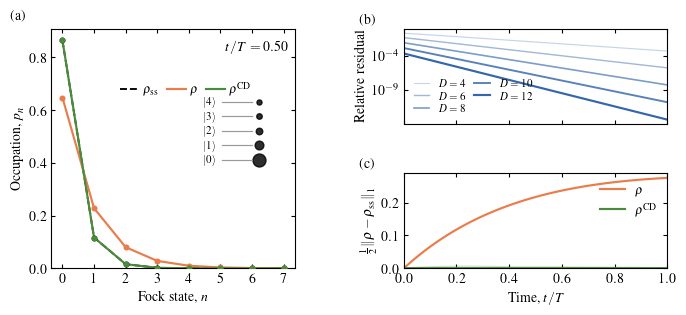

In [10]:
reference_dim = max(DIMS)
reference = results[reference_dim]
show_index = np.argmin(
    np.abs(reference["times"] / T - SHOW_TIME_FRACTION)
)

n_shown = min(MAX_FOCK_SHOWN, reference_dim)
n = np.arange(n_shown)
p_ss = np.real(np.diag(reference["rho_ss"][show_index]))[:n_shown]
p_bare = np.real(np.diag(reference["rho_bare"][show_index]))[:n_shown]
p_cd = np.real(np.diag(reference["rho_cd"][show_index]))[:n_shown]

strengths = np.linspace(0.28, 1.00, len(DIMS))
line_widths = np.linspace(0.85, 1.55, len(DIMS))
alpha = dict(zip(DIMS, strengths))
line_width = dict(zip(DIMS, line_widths))

fig = plt.figure(figsize=(7.0, 3.05))
outer = fig.add_gridspec(1, 2, width_ratios=[0.48, 0.52], wspace=0.43)
ax_occ = fig.add_subplot(outer[0, 0])
right = outer[0, 1].subgridspec(2, 1, hspace=0.52)
ax_res = fig.add_subplot(right[0, 0])
ax_err = fig.add_subplot(right[1, 0])

# (a) Occupations: the physical picture of cooling.
ax_occ.plot(n, p_ss, "--", color=BLACK, lw=1.35, label=r"$\rho_{\rm ss}$")
ax_occ.plot(n, p_bare, color=ORANGE, lw=1.55, label=r"$\rho$")
ax_occ.plot(n, p_cd, color=GREEN, lw=1.55, label=r"$\rho^{\rm CD}$")
ax_occ.scatter(n, p_ss, s=12, facecolor="white", edgecolor=BLACK,
               linewidth=0.75, zorder=5)
ax_occ.scatter(n, p_bare, s=11, color=ORANGE, zorder=5)
ax_occ.scatter(n, p_cd, s=11, color=GREEN, zorder=5)
ax_occ.set(xlabel=r"Fock state, $n$", ylabel=r"Occupation, $p_n$",
           xlim=(-0.35, n_shown - 0.65), ylim=(0, None))
ax_occ.set_xticks(n)
ax_occ.text(0.97, 0.95, rf"$t/T={reference['times'][show_index]/T:.2f}$",
            transform=ax_occ.transAxes, ha="right", va="top")
ax_occ.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.55, 0.80),
              ncol=3, handlelength=1.5, handletextpad=0.35,
              columnspacing=0.75, borderaxespad=0.0)

# Small energy ladder; bubble area encodes the target occupation.
ax_ladder = ax_occ.inset_axes([0.63, 0.42, 0.27, 0.32])
ax_ladder.set_axis_off()
n_ladder = min(5, n_shown)
for level in range(n_ladder):
    ax_ladder.plot([0.12, 0.70], [level, level], color=MID_GREY, lw=0.85)
    ax_ladder.text(0.03, level, rf"$|{level}\rangle$", ha="right", va="center", fontsize=8)
    marker_size = 12 + 75 * np.sqrt(p_ss[level] / max(p_ss[:n_ladder].max(), 1e-15))
    ax_ladder.scatter([0.84], [level], s=marker_size, color=BLACK, alpha=0.82)
ax_ladder.set(xlim=(-0.2, 1.05), ylim=(-0.55, n_ladder - 0.25))

# (b) Variational residual: one blue family, darker for larger D.
for dim in DIMS:
    data = results[dim]
    ax_res.plot(data["times"] / T, np.maximum(data["residuals"], 1e-16),
                color=BLUE, alpha=alpha[dim], lw=line_width[dim],
                label=rf"$D={dim}$")
ax_res.set_yscale("log")
ax_res.set(xlim=(0, 1), ylabel=r"Relative residual")
ax_res.tick_params(labelbottom=False)
ax_res.legend(frameon=False, loc="best", ncol=2, fontsize=8,
              handlelength=1.4, labelspacing=0.2, columnspacing=0.8)

# (c) One bare curve and the converging CD family.
ax_err.plot(reference["times"] / T, reference["error_bare"],
            color=ORANGE, lw=1.55)
for dim in DIMS:
    data = results[dim]
    ax_err.plot(data["times"] / T, data["error_cd"], color=GREEN,
                alpha=alpha[dim], lw=line_width[dim])
ax_err.set(xlim=(0, 1), ylim=(0, None), xlabel=r"Time, $t/T$",
           ylabel=r"$\frac{1}{2}\|\rho-\rho_{\rm ss}\|_1$")
ax_err.legend(handles=[
    Line2D([0], [0], color=ORANGE, lw=1.55, label=r"$\rho$"),
    Line2D([0], [0], color=GREEN, lw=1.55, label=r"$\rho^{\rm CD}$"),
], frameon=False, loc="upper right", handlelength=2.0)

for label, axis in zip([r"(a)", r"(b)", r"(c)"], [ax_occ, ax_res, ax_err]):
    axis.text(-0.17, 1.03, rf"{label}" if USE_TEX else label,
              transform=axis.transAxes, ha="left", va="bottom", clip_on=False)
    axis.tick_params(which="major", length=3.0, width=0.8)
    axis.tick_params(which="minor", length=1.8, width=0.6)

fig.subplots_adjust(left=0.105, right=0.985, bottom=0.18, top=0.965)
if SAVE_FIGURE:
    fig.savefig(OUTPUT_NAME, bbox_inches="tight", pad_inches=0.03)
plt.show()
